### Получаем данные

In [1]:
from src.mlcore.dataloader import get_processed_data

raw = get_processed_data(
    source="raw",
    symbol="BTCUSDC",
    drop_last=True,
    save_dir="parquets/",
    grid_resolution_ms=5000,
)
raw

orderbook_snapshots: 100%|██████████| 1304/1304 [33:28<00:00,  1.54s/it] 


,exchange_ts,open,high,low,close,volume,volume_1s,buy_volume_1s,sell_volume_1s,volume_imbalance_1s,...,ask_qty_90,ask_qty_91,ask_qty_92,ask_qty_93,ask_qty_94,ask_qty_95,ask_qty_96,ask_qty_97,ask_qty_98,ask_qty_99
0,2026-01-23 11:50:30,89130.601562,89139.500000,89130.500000,89135.101562,0.769,0.000,0.000,0.000,0.000000,...,0.014,1.000,0.139,0.002,0.005,0.141,1.796,0.821,0.006,0.139
1,2026-01-23 11:50:35,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.196,0.000,0.196,-1.000000,...,0.139,0.002,0.139,0.744,0.139,1.010,1.796,0.139,0.112,1.139
2,2026-01-23 11:50:40,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.000,0.000,0.000,0.000000,...,0.020,0.023,0.139,1.094,0.139,1.075,1.796,0.139,1.008,1.139
3,2026-01-23 11:50:45,89130.398438,89130.398438,89128.000000,89128.101562,0.232,0.000,0.000,0.000,0.000000,...,0.002,0.139,1.094,0.139,1.122,1.796,0.139,1.011,0.112,1.307
4,2026-01-23 11:50:50,89128.101562,89128.101562,89128.101562,89128.101562,0.002,0.004,0.000,0.004,-1.000000,...,0.005,0.139,0.415,0.003,0.139,0.004,0.139,0.978,0.139,0.744
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938269,2026-03-18 18:59:35,70999.296875,71008.296875,70999.203125,71008.296875,0.590,0.035,0.035,0.000,1.000000,...,0.010,0.020,0.006,0.002,0.007,1.180,0.014,0.072,0.034,0.004
938270,2026-03-18 18:59:40,71028.898438,71031.000000,71010.000000,71019.601562,1.378,0.211,0.000,0.211,-1.000000,...,0.013,0.037,0.007,0.014,0.088,0.010,0.004,0.002,0.003,0.036
938271,2026-03-18 18:59:45,71022.398438,71031.500000,71012.101562,71018.000000,2.856,0.510,0.041,0.469,-0.839216,...,0.003,0.004,0.002,0.020,0.004,0.010,0.033,0.002,0.002,0.005
938272,2026-03-18 18:59:50,71033.898438,71037.898438,71018.203125,71026.296875,4.252,4.000,4.000,0.000,1.000000,...,0.009,0.002,0.002,0.008,0.016,0.002,0.003,0.002,0.342,0.020


### Определяем таргеты для всех моделей

In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm


def calculate_mid_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        mid = (df['high'].iloc[i+1] + df['low'].iloc[i+1]) / 2.0
        target[i] = np.log(mid / current)
    return pd.Series(target, index=df.index)


def calculate_spread_target(df: pd.DataFrame):
    target = np.zeros(len(df), dtype=float)
    for i in tqdm(range(len(df) - 1)):
        current = df['close'].iloc[i]
        spread = df['high'].iloc[i+1] - df['low'].iloc[i+1]
        target[i] = spread / current
    return pd.Series(target, index=df.index)


mid_target = calculate_mid_target(raw)
spread_target = calculate_spread_target(raw)

100%|██████████| 938273/938273 [00:08<00:00, 115948.58it/s]


### Генерируем фичи для всех моделей

In [3]:
from src.mlcore.dataloader import calculate_features

df = calculate_features(raw, filename='all_features')
df['low'] = raw['low']
df['high'] = raw['high']
df['close'] = raw['close']
df['mid_target'] = mid_target
df['spread_target'] = spread_target
df.dropna(inplace=True)
df

,adverse_selection_risk,ask_price_pressure,atr,atr_exponential_smoothing_alpha_0_8,bid_ask_cancellation_proxy5,bid_ask_spread_tightness_index,bid_price_pressure,combo16_weighted_orderbook_log_times_slope,combo29_response_imbalance_log1p_times_wli,combo35_fqi_rolling_std_18_times_slope,...,volatility_contraction_expansion_ratio,weighted_depth_ratio,weighted_log_imbalance_5levels,weighted_orderbook_imbalance,weighted_price_pressure,low,high,close,mid_target,spread_target
30,1.720052,4.470000,4.350781,4.826048,1.591322e-04,1.720241,0.399000,-0.282542,-0.043540,-3.870383,...,0.145161,0.862152,-0.825813,-0.537971,-0.540668,89142.398438,89150.796875,89145.703125,0.000001,0.000000
31,1.673307,0.248484,4.208880,4.584924,2.141049e-04,1.673463,0.588047,3.569189,0.434759,32.839458,...,0.137839,4.493296,4.811982,0.943113,0.945398,89145.796875,89145.796875,89145.796875,0.000000,0.000000
32,1.826563,0.965219,4.068584,4.278148,2.752305e-04,1.826706,0.176813,2.594957,0.397548,28.002368,...,0.137839,3.452995,3.723537,0.751790,0.752639,89145.796875,89145.796875,89145.796875,0.000000,0.000000
33,1.826563,0.026508,3.932965,3.976710,4.429674e-04,1.826679,0.055969,0.989410,0.123907,17.214146,...,0.134221,2.117040,2.170741,0.394916,0.393676,89145.796875,89145.796875,89145.796875,0.000051,0.000001
34,1.788281,0.026914,3.955251,3.956434,9.560574e-04,1.788374,0.056250,0.976829,0.122001,16.139879,...,0.141591,2.066252,2.160544,0.390597,0.389091,89150.296875,89150.398438,89150.398438,0.000020,0.000039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938269,13.506510,0.211078,29.779986,28.002047,1.161449e-10,13.506491,0.804102,0.430221,0.174187,32.658369,...,0.808455,2.599751,2.425044,0.130642,0.118652,70999.203125,71008.296875,71008.296875,0.000172,0.000296
938270,13.676562,0.104789,29.544091,27.507998,3.346098e-10,13.676543,0.634711,2.477449,1.441366,41.871154,...,0.813742,1.342351,3.769341,0.707995,0.714995,71010.000000,71031.000000,71019.601562,0.000031,0.000273
938271,13.446615,2.011500,29.205903,26.952842,3.171716e-09,13.446595,0.046148,-3.229473,-2.361608,-46.174065,...,0.757953,0.221395,-4.624701,-0.933963,-0.946869,71012.101562,71031.500000,71018.000000,0.000142,0.000277
938272,14.161589,0.023359,28.895654,26.446633,5.572984e-09,14.161509,0.342297,-0.904286,-0.653282,-25.950377,...,0.768208,0.483829,-1.609756,0.352384,-0.195964,71018.203125,71037.898438,71026.296875,0.000515,0.001036


In [4]:
feature_columns = [col for col in df.columns if col not in ['mid_target', 'spread_target', 'close', 'high', 'low']]
X = df[feature_columns].copy()
y_mid = df['mid_target'].copy()
y_spread = df['spread_target'].copy()
ohlcv = df[['close', 'high', 'low']].copy()

split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_mid_train, y_mid_test = y_mid.iloc[:split_index], y_mid.iloc[split_index:]
y_spread_train, y_spread_test = y_spread.iloc[:split_index], y_spread.iloc[split_index:]
_, ohlcv_test = ohlcv.iloc[:split_index], ohlcv.iloc[split_index:]

### Обучаем mid model

In [5]:
from src.mlcore.train import train_regression_model

mid_model = train_regression_model(
    X_train=X_train,
    y_train=y_mid_train,
    X_test=X_test,
    y_test=y_mid_test,
    n_estimators=5000,
    objective='reg:squarederror',
    model_name="model_mid",
    max_depth=3,
)

Обучение модели...
[0]	validation_0-rmse:0.00018
[50]	validation_0-rmse:0.00017
[100]	validation_0-rmse:0.00017
[150]	validation_0-rmse:0.00017
[200]	validation_0-rmse:0.00017
[250]	validation_0-rmse:0.00016
[300]	validation_0-rmse:0.00016
[350]	validation_0-rmse:0.00016
[400]	validation_0-rmse:0.00016
[450]	validation_0-rmse:0.00016
[500]	validation_0-rmse:0.00016
[550]	validation_0-rmse:0.00016
[600]	validation_0-rmse:0.00016
[650]	validation_0-rmse:0.00016
[700]	validation_0-rmse:0.00016
[750]	validation_0-rmse:0.00016
[800]	validation_0-rmse:0.00016
[850]	validation_0-rmse:0.00016
[900]	validation_0-rmse:0.00016
[950]	validation_0-rmse:0.00016
[1000]	validation_0-rmse:0.00016
[1050]	validation_0-rmse:0.00016
[1100]	validation_0-rmse:0.00016
[1150]	validation_0-rmse:0.00016
[1200]	validation_0-rmse:0.00016
[1250]	validation_0-rmse:0.00016
[1300]	validation_0-rmse:0.00016
[1350]	validation_0-rmse:0.00016
[1400]	validation_0-rmse:0.00016
[1450]	validation_0-rmse:0.00016
[1500]	validat

MAE                      : 0.000100
RMSE                     : 0.000161
R²                       : 0.237118
MAE / mean|Δ|            : 0.842271
RMSE / RMSE_base         : 0.873417
mean|Δ| (target)         : 0.000119

------------------------------------------------------------
Directional Accuracy     : 0.632015
Target Pos Ratio         : 0.477109
Profit Factor            : 1.648771
Avg Gain (correct)       : -0.000004
Avg Loss (incorrect)     : 0.000005

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.6300, 0.6344)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc  mean_return  n_samples
 (0.000113, 0.00118]    0.000210         0.913243    -0.000003      18765
(6.29e-05, 0.000113]    0.000083         0.794298    -0.000006      18765
(4.36e-05, 6.29e-05]    0.000052         0.720970    -0.000003      18765


/Users/honeysuckle/dev/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


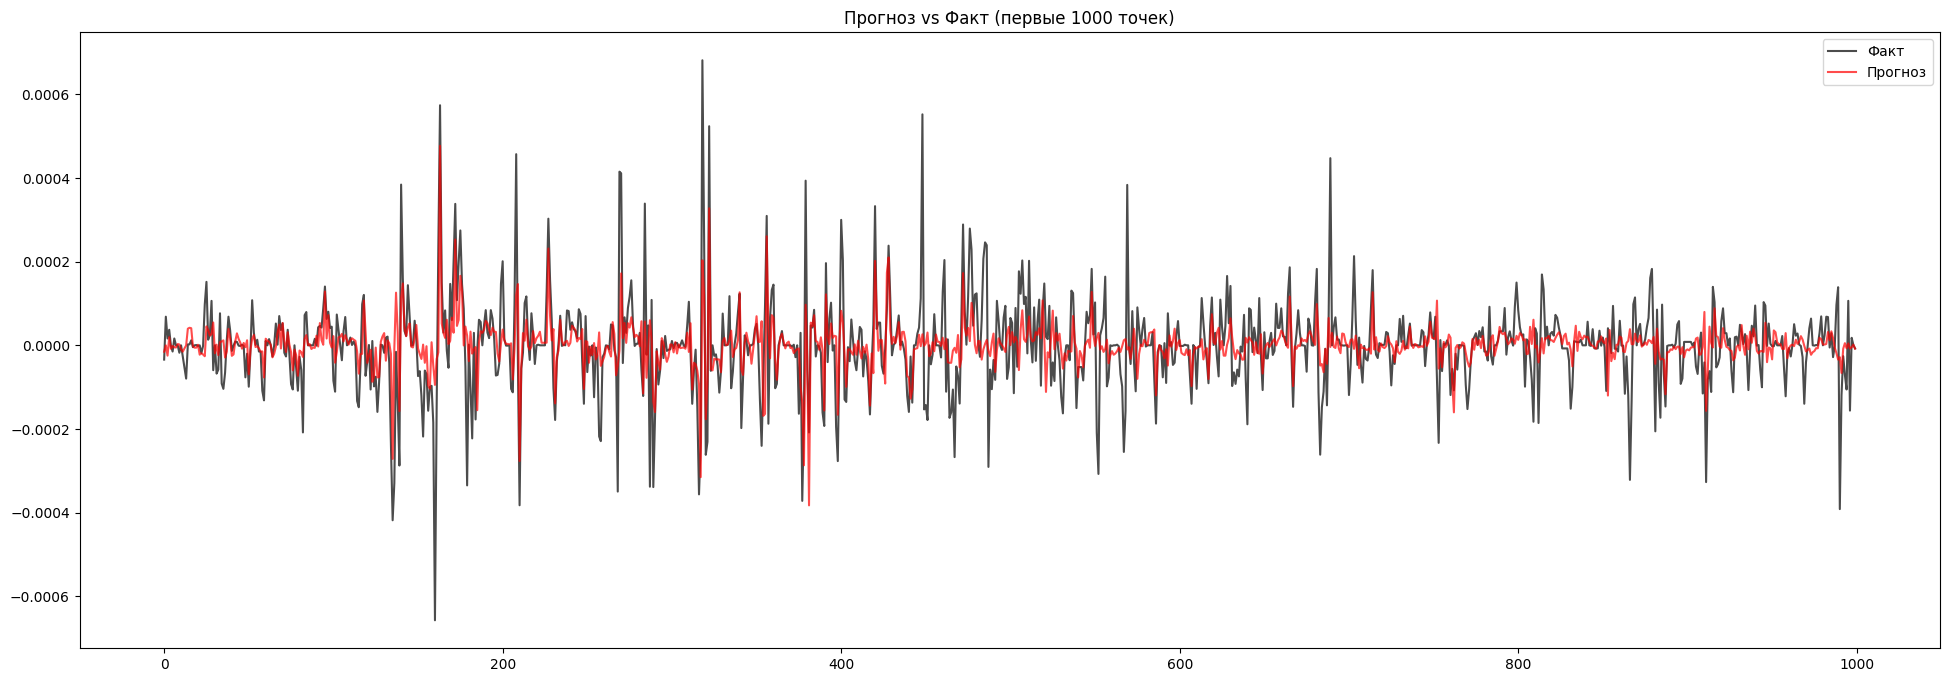

In [6]:
from src.mlcore.evaluation import evaluate_regression_model

y_mid_pred = mid_model.predict(X_test)

evaluate_regression_model(
    y_test=y_mid_test,
    y_pred=y_mid_pred,
    length=1000,
)

### Обучаем spread model

In [7]:
from src.mlcore.train import train_regression_model

spread_model = train_regression_model(
    X_train=X_train,
    y_train=y_spread_train,
    X_test=X_test,
    y_test=y_spread_test,
    n_estimators=5000,
    objective='reg:squaredlogerror',
    model_name="model_spread",
    max_depth=6,
)

Обучение модели...


[0]	validation_0-rmse:0.00020
[50]	validation_0-rmse:0.00017
[100]	validation_0-rmse:0.00016
[150]	validation_0-rmse:0.00016
[200]	validation_0-rmse:0.00016
[250]	validation_0-rmse:0.00016
[300]	validation_0-rmse:0.00016
[350]	validation_0-rmse:0.00016
[400]	validation_0-rmse:0.00016
[450]	validation_0-rmse:0.00016
[500]	validation_0-rmse:0.00016
[550]	validation_0-rmse:0.00016
[600]	validation_0-rmse:0.00016
[650]	validation_0-rmse:0.00016
[700]	validation_0-rmse:0.00016
[750]	validation_0-rmse:0.00016
[800]	validation_0-rmse:0.00016
[850]	validation_0-rmse:0.00016
[851]	validation_0-rmse:0.00016
Модель сохранена в директорию: models/model_spread.json


MAE                      : 0.000104
RMSE                     : 0.000156
R²                       : 0.376535
MAE / mean|Δ|            : 0.591177
RMSE / RMSE_base         : 0.589501
mean|Δ| (target)         : 0.000176

------------------------------------------------------------
Directional Accuracy     : 0.901705
Target Pos Ratio         : 0.901705
Profit Factor            : 33032794818.751125
Avg Gain (correct)       : 0.000195
Avg Loss (incorrect)     : 0.000000

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.9003, 0.9030)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc  mean_return  n_samples
 (0.000342, 0.00193]    0.000462         0.999680     0.000453      18765
(0.000254, 0.000342]    0.000293         0.997282     0.000290      18765
(0.000206, 0.000254]    0.000228         0.988169     0.000225    

/Users/honeysuckle/dev/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


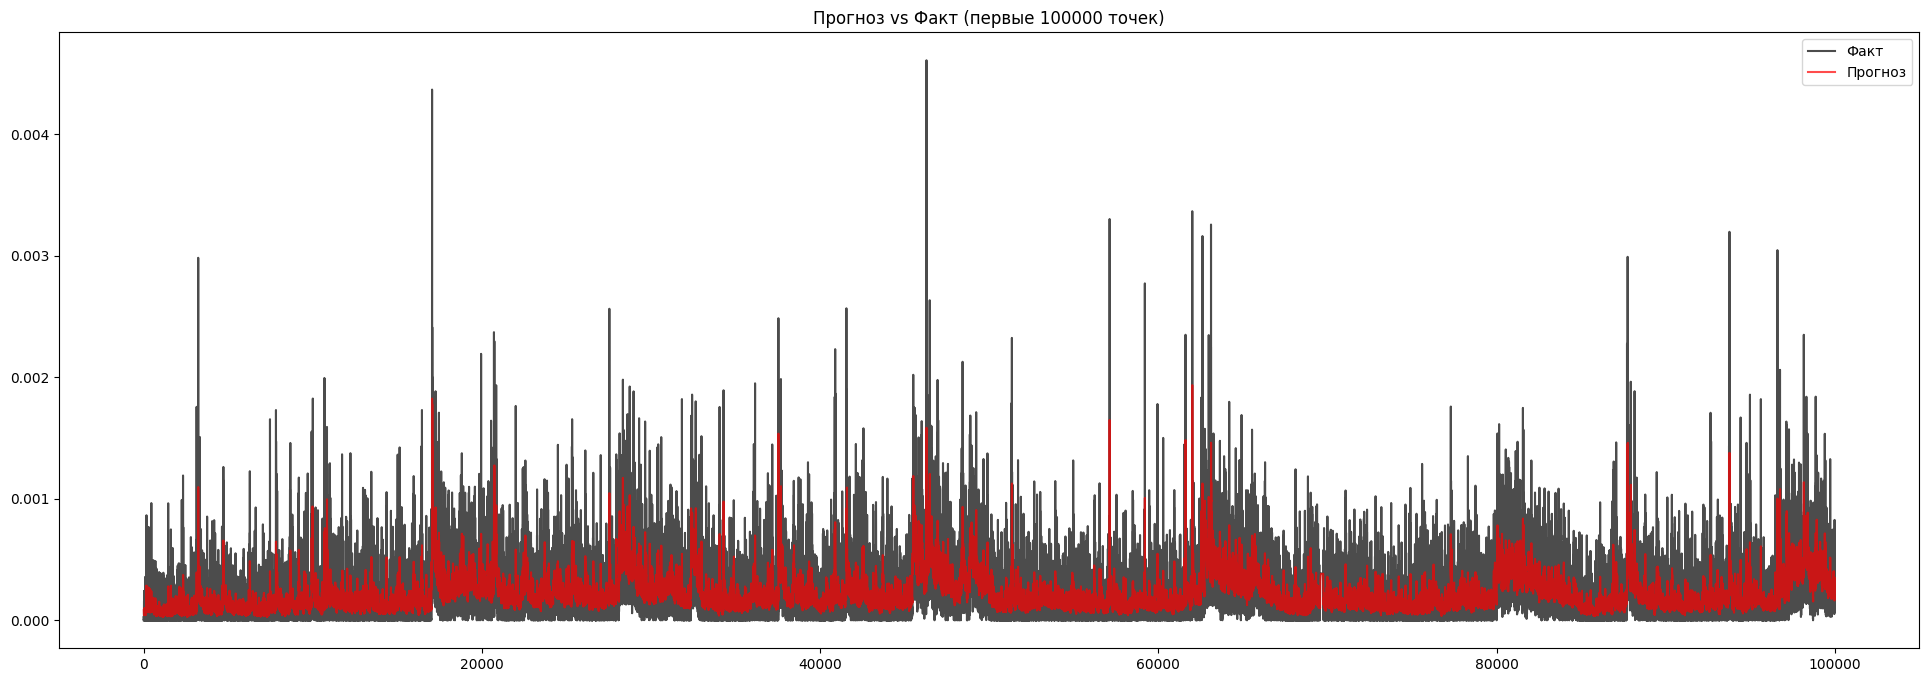

In [8]:
from src.mlcore.evaluation import evaluate_regression_model

y_spread_pred = spread_model.predict(X_test)

evaluate_regression_model(
    y_test=y_spread_test,
    y_pred=y_spread_pred,
    length=100000,
)